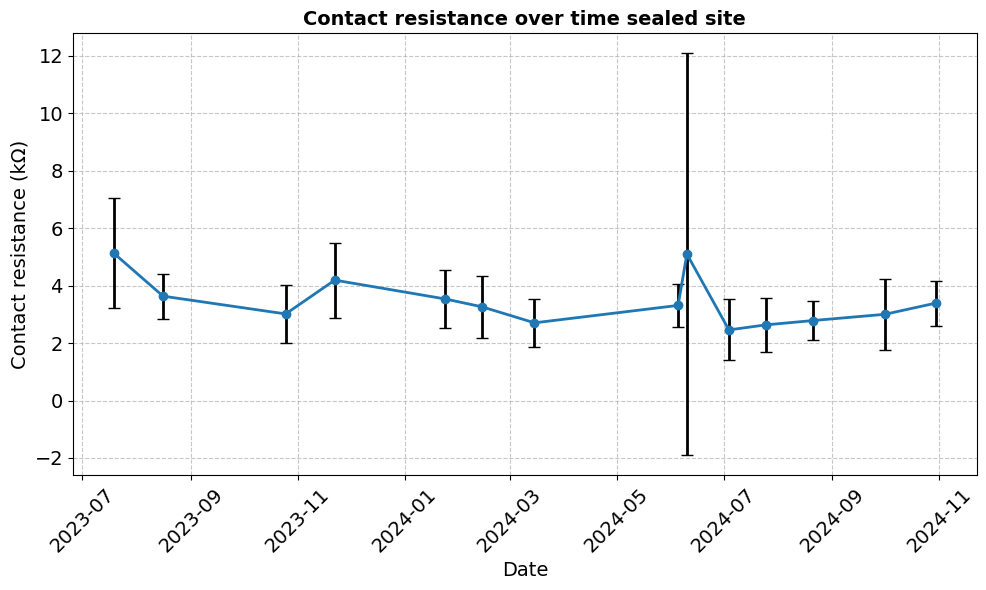

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Hauptverzeichnis, in dem die Datumsordner liegen
base_dir = "./Data/all_timesteps/"

# Regex für Datumsordner: z. B. '240809'
date_pattern = re.compile(r"^\d{6}$")

results = []

for folder in sorted(os.listdir(base_dir)):
    if date_pattern.match(folder):
        file_path = os.path.join(base_dir, folder, "Ankopplung/Ankopplung1.atc")
        if os.path.isfile(file_path):
            with open(file_path, encoding="utf-8") as f:
                lines = f.readlines()

            data_lines = []
            for line in lines:
                if line.strip().startswith("//") or not line.strip():
                    continue
                parts = line.split()
                if len(parts) >= 2 and parts[0].isdigit():
                    data_lines.append(parts)

            values = [float(row[-2]) for row in data_lines]
            mean_val = np.mean(values)
            std_val = np.std(values, ddof=1)

            results.append({
                "date": pd.to_datetime(folder, format="%y%m%d"),
                "mean": mean_val,
                "std": std_val
            })

df = pd.DataFrame(results).sort_values("date")

# Plot
plt.figure(figsize=(10, 6))
plt.errorbar(
    df["date"], 
    df["mean"], 
    yerr=df["std"], 
    fmt='o-', 
    ecolor='black', 
    color='#1f77b4',  # Matplotlib Standardblau
    capsize=4, 
    markersize=6, 
    linewidth=2
)

plt.xlabel("Date", fontsize=14)
plt.ylabel("Contact resistance (kΩ)", fontsize=14)
plt.title("Contact resistance over time sealed site", fontsize=14, weight='bold')
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('./Ankopplung/' + 'Ankopplung.png', bbox_inches = 'tight', dpi=300)

plt.show()
